In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [4]:
df=pd.read_csv("/home/vivekananda-reddy/Desktop/Python/ML Project/data.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP


In [5]:
#checking null values
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                     0
order_delivered_carrier_date       1235
order_delivered_customer_date      2471
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             103402


In [6]:
# df = df[df['order_status']=='delivered']

In [7]:
# df=df.dropna(subset=['order_delivered_customer_date'])
# df=df.dropna(subset=['order_delivered_carrier_date'])

In [8]:
# df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
# df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [9]:
# df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days


In [10]:
#creating separate customer dataframe
cus_df = df.groupby('customer_unique_id').agg({
    'order_id': 'count',               
    'payment_value': 'sum',  
                        
}).reset_index()

#changing the col names
cus_df.columns = [
    'customer_id',
    'total_orders',
    'total_spent'
]

In [11]:
#customer dataframe top 5
cus_df.head()

,customer_id,total_orders,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


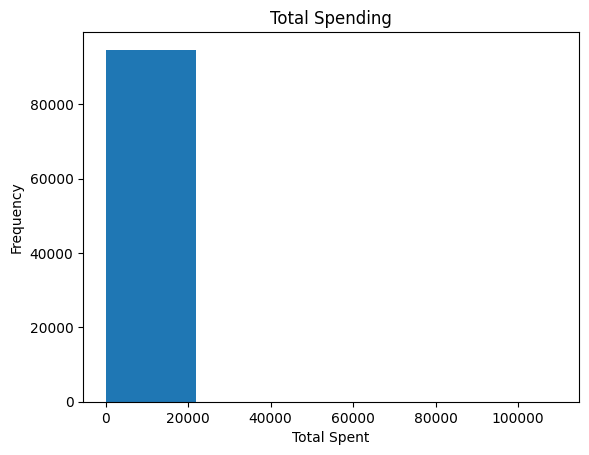

In [12]:
#plotting the total spent of customer
plt.hist(cus_df['total_spent'], bins=5)
plt.title("Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Total Spent')

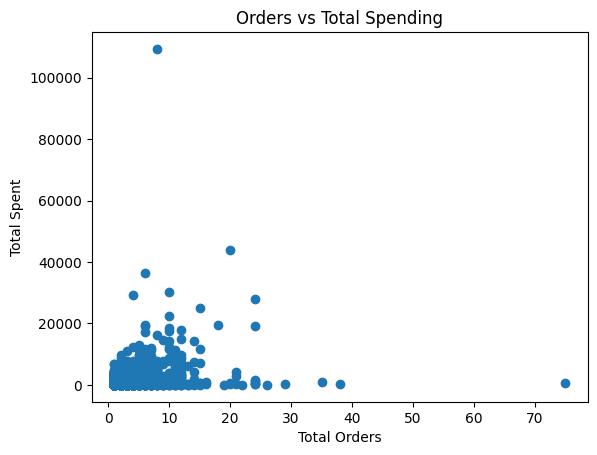

In [ ]:
#plotting the scatter plot orders vs total spending
plt.scatter(cus_df['total_orders'], cus_df['total_spent'])
plt.title("Orders vs Total Spending")
plt.xlabel("Total Orders")
plt.ylabel("Total Spent")

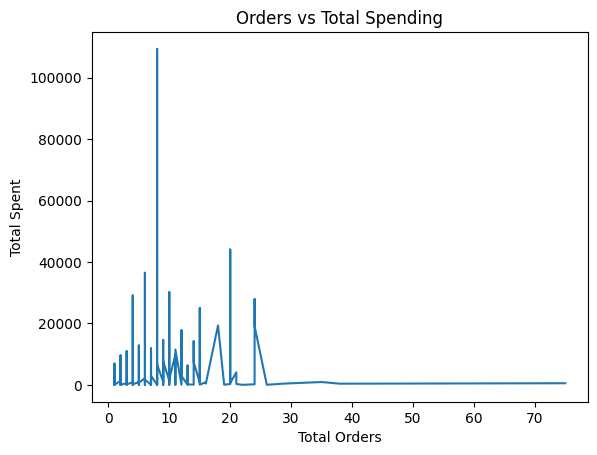

In [ ]:
#plotting a line graph
cus_df_sorted = cus_df.sort_values('total_orders')

plt.plot(cus_df_sorted['total_orders'], cus_df_sorted['total_spent'])
plt.title("Orders vs Total Spending")
plt.xlabel("Total Orders")
plt.ylabel("Total Spent")
plt.show()

In [15]:
#scaling
features = [
    'total_orders',
    'total_spent'
]

X_cluster = cus_df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

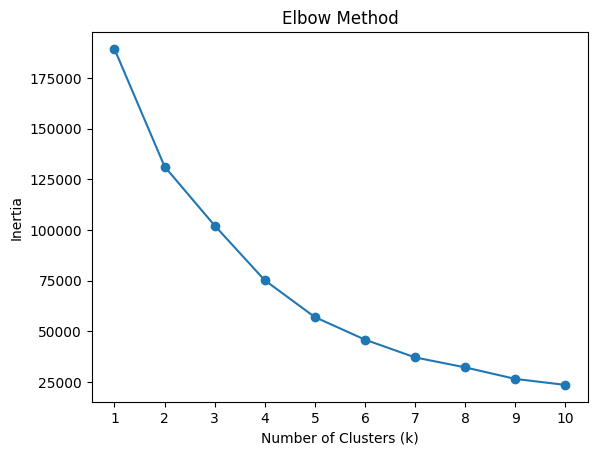

In [ ]:

#finding the optimal k
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xticks(range(1, 11))
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [17]:
#Apllying KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
cus_df['cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
#cluster summary
cluster_summary = cus_df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         total_orders    total_spent
cluster                             
0            1.112494     168.707549
1            3.862972     982.083922
2            8.000000  109312.640000
3           12.850575   10157.578161


In [19]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [20]:
centroids_org = scaler.inverse_transform(centroids)

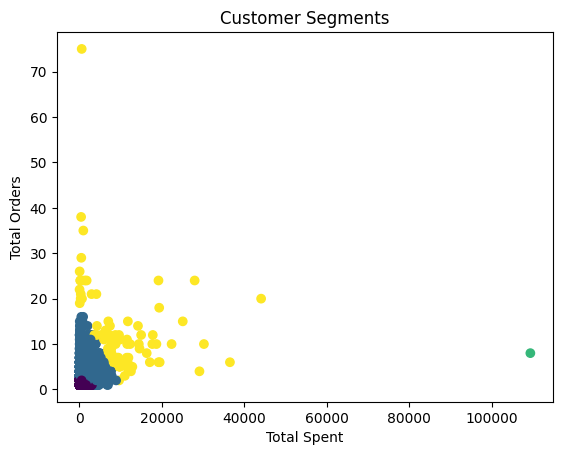

In [ ]:
#plotting the customer seg graph
plt.scatter(cus_df['total_spent'], cus_df['total_orders'], c=cus_df['cluster'])
plt.title("Customer Segments")
plt.xlabel("Total Spent")
plt.ylabel("Total Orders")
plt.show()

In [22]:
#Finding silhouette score
score = silhouette_score(X_scaled, labels)
print(score)

0.8480375380204055
